In [1]:
# %debug
# %load_ext autoreload
# %autoreload 2

import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt
import os,sys
from pathlib import Path

# NOTE: My .py files
from standardizing_data import (
    standardize_lc,
    get_tess_lc,
    _get_colors,
    collect_lightcurves_for_target,
    # constants
    DEFAULT_RADIUS,
    DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH
)


from phasefold import phasefold, plot_phasefolded
from astropy.stats import sigma_clip

# Read in catalog data

In [2]:
catalog_dir = (Path.cwd() / "../Catalog/").resolve()

nearby_TOI_MD_df=pd.read_csv(f'{catalog_dir}/nearby_TOI_MDs.csv')
nearby_TOI_MD_df.head(5)

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
0,0,spoc-s01-s36-b0A-CPKP,SPOC,410153553,136.01,PC,340.492100,-69.169000,340.496204,-69.172108,11.877,0.064,1325.724661,0.000156,0.462931,3.872269e-06,0.631015,0.022202,4677.673602,171.681260,"1,27,28,67,68,94,95,101,102,103,104",LHS 3844 b,5.09707,0.426694,1,0.188624,0.005710,1.517197,0.061800,723.372047,3043.0,63.0,64.709477,38.885654,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2020-10-27 13:01:47.547000+00:00,410153553,340.492156,-69.168978,334.3570,-726.9740,11.92380,STAR,tmgaia2,20190415,NaN,NaN,105-116381,22415815-6910089,NaN,NaN,6385548541499112448,33464847.0,NaN,tmgaia2,0.082820,0.086335,gaia2,67.15480,0.050599,gaia2,318.253844,-43.907555,304.887051,-54.122569,16.942,0.041,15.240,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.046,0.023,9.477,0.023,9.145,0.023,AAA-222-111-000-0-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3925,0.000738,0.007698,cdwrf,cdwrf,3004.0,157.0,5.08528,0.029186,NaN,NaN,0.188624,0.005710,0.157909,0.020067,23.52970,0.863072,DWARF,0.002610,0.000708,14.8846,0.0113,0.000000,0.000000,81.0,0.010833,NaN,NaN,0.009687,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,0.0113,bj2018,NaN,NaN,cdwrf,15.4512,0.007263,12.05170,0.002827,1,NaN,cdwrf,apassdr9,cooldwarfs_v8,1.559812,1.338867,340.496204,-69.172108,0.041207,0.042399,1,0,0.0,0.1933,0.5347,1.570796,2.913518,8.243782,328.631928,NaN,8.866874e+07,64.915025,11.0,"3,3,3,2,2,2,2,4,4,3,3","2,1,2,2,1,2,1,3,2,3,2","0,0,0,0,0,0,0,0,0,0,0"
1,1,spoc-s01-s69-b0A-CP,SPOC/QLP,234994474,134.01,CP,350.031300,-60.065200,350.028592,-60.065729,9.169,0.019,1326.034032,0.000566,1.401518,4.810232e-06,1.158306,0.325507,593.754092,42.808456,"1,28,68,95,102,104,105",L 168-9 b,4.67812,0.063226,1,0.597007,0.018150,1.461685,1.838503,891.638989,3794.0,69.0,149.374754,20.450527,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2024-09-30 23:32:46.016000+00:00,234994474,350.031352,-60.065179,-319.9610,-127.7810,9.22978,STAR,tmgaia2,20190415,115211.0,9126-00748-1,150-224713,23200751-6003545,NaN,NaN,6491962296196145664,31785853.0,NaN,tmgaia2,0.102122,0.115073,gaia2,39.73310,0.037526,gaia2,321.954596,-53.560374,319.217901,-49.527946,12.460,0.025,11.005,0.018,Na

# Creating a workflow from existing tools

In [3]:
def timer(start,end,message):
    """
    Print the wall-clock runtime of a pipeline step in human-readable units.

    Automatically selects seconds, minutes, or hours based on the elapsed
    time so that log output is always legible regardless of step duration.
    Designed for inline use at the end of each named pipeline step.

    Parameters
    ----------
    start : float
        Start timestamp in seconds, as returned by ``time.time()``.
    end : float
        End timestamp in seconds, as returned by ``time.time()``.
    message : str
        Label printed before the runtime, e.g. ``'SAP took:'``.

    Returns
    -------
    None
        Prints to stdout; does not return a value.

    Notes
    -----
    Uses ``astropy.units`` for unit conversion.  Output format is:

        ``<message> <value> seconds|minutes|hours``

    The unit boundaries are: < 1 min → seconds; 1–60 min → minutes;
    ≥ 60 min → hours.

    Examples
    --------
    >>> import time
    >>> t0 = time.time()
    >>> # ... some computation ...
    >>> timer(t0, time.time(), 'SAP took:')
    SAP took: 4.231 seconds
    """
    import astropy.units as u
    runtime = (end-start)*u.second
    if runtime.to(u.minute) < 1*u.minute:
        print(message, np.round(runtime.value,3),'seconds \n')
    if (runtime.to(u.minute) >= 1*u.minute) & (runtime.to(u.minute) < 60*u.minute):
        print(message, np.round((runtime.to(u.minute)).value,3),'minutes \n')        
    if (runtime.to(u.minute) >= 60*u.minute):
        print(message, np.round((runtime.to(u.hour)).value,3),'hours \n')                


def target_to_lightcurve_workflow(target, pipelines, target_Sector,
                                  DEFAULT_RADIUS, 
                                  DEFAULT_CADENCE, 
                                  DEFAULT_DOWNLOADPATH):
    import time as clock
    t_start = clock.time()
    
    ID = target['TIC ID'].item()
    target_P= target['Orbital Period (days) Value'].item()
    target_T0= target['Orbital Epoch Value'].item()
    target_Dep = target['Transit Depth Value'].item()/1e6
    target_Dur = target['Transit Duration (hours) Value'].item()
    if target_Sector is None:
        try:
            target_Sector = np.min(list(map(int, target['Sectors'].to_list()[0].split(',')))) #choosing 1st sector
        except AttributeError:
            target_Sector = np.min(list(map(int, target['Sectors'].split(',')))) #choosing 1st sector
    
    
    sector_results = collect_lightcurves_for_target(
    tic_id=ID,
    sector=target_Sector, 
    pipelines=pipelines,
    downloadpath=DEFAULT_DOWNLOADPATH,
    radius=DEFAULT_RADIUS,
    exptime=DEFAULT_CADENCE,
    apply_quality_mask=True,
    verbose=True
)
    
    # phasefolded comparison:
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    corrected_epochs = {}

    epoch_btjd = target_T0
    period = target_P

    sector_all_flux_unclipped = []
    sector_all_flux_clipped = []

    for i in range(len(pipelines)):
        p = pipelines[i]
        info = sector_results[p]
        C = pipeline_colors[i]

        if info["status"] != "ok":
            #print(f"Skipping {p}: {info['error']}")
            corrected_epochs[p] = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]

        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            continue

        t_first = lc_to_plot["time"].min()

        flux = lc_to_plot["flux_corr"].to_numpy()
        n_first = int(np.ceil((t_first - epoch_btjd) / period))
        # NOTE: the nearrest predicted transit
        corrected_epochs[p] = epoch_btjd + n_first * period
        flux_norm = flux / np.nanmedian(flux)

        clipped = sigma_clip(flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5)
        good = ~clipped.mask
        lc_clean = lc_to_plot.iloc[good]

        n_total = len(flux_norm)
        print(f"{p}: total {n_total} points")
        n_removed = np.sum(clipped.mask)
        print(f"{p}: removed {n_removed} points")

        plot_phasefolded(
            ax=axes[0],
            target=target,
            lc=lc_to_plot,
            color=C,
            label=p,
            T0=corrected_epochs[p]
        )

        plot_phasefolded(
            ax=axes[1],
            target=target,
            lc=lc_clean,
            color=C,
            label=p,
            T0=corrected_epochs[p]
        )

        sector_all_flux_unclipped.append(flux_norm)
        sector_all_flux_clipped.append(flux_norm[good])

    if len(sector_all_flux_unclipped) > 0:
        all_flux_unclipped = np.concatenate(sector_all_flux_unclipped)
        axes[0].set_ylim(
            np.nanpercentile(all_flux_unclipped, 1),
            np.nanpercentile(all_flux_unclipped, 99)
        )

    if len(sector_all_flux_clipped) > 0:
        all_flux_clipped = np.concatenate(sector_all_flux_clipped)
        axes[1].set_ylim(
            np.nanpercentile(all_flux_clipped, 1),
            np.nanpercentile(all_flux_clipped, 99)
        )

    for ax in axes:
        #ax.set_xlim(-3, 3)
        #ax.set_xlabel(f"Orbital Phase [Hours since {np.round(target['Orbital Epoch Value'].item(), 4)} BTJD]")
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, Sector {target_Sector}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, Sector {target_Sector}")

    plt.tight_layout()
    plt.show()
    
    print(' ')
    print('================================')
    timer(t_start, clock.time(), "target_to_lightcurve_workflow function took:")
    print(' ')
    print('================================')
    return sector_results
    

In [4]:
#TOI-270 c (~5.66 d period, 2.4 Earth radii planet)
target = nearby_TOI_MD_df.loc[nearby_TOI_MD_df['TIC ID'].astype(int)==259377017].reset_index(drop=True).iloc[0]



pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
pipeline_colors = _get_colors(len(pipelines))

Fetching QLP for TIC 259377017, sector 3
Selected product row:
  target_name pipeline mission  sector  exptime  distance  year description
0   259377017      QLP    HLSP       3   1800.0       0.0  2018        FITS
choose_first_timeseries=True; sorted using: t_min
Fetching TESS-SPOC for TIC 259377017, sector 3
Selected product row:
  target_name   pipeline mission  sector  exptime  distance  year description
0   259377017  TESS-SPOC    HLSP       3   1800.0       0.0  2018        FITS
choose_first_timeseries=True; sorted using: t_min
Fetching TGLC for TIC 259377017, sector 3
Selected product row:
  target_name pipeline mission  sector  exptime  distance  year description
0   259377017     TGLC    HLSP       3   1800.0   0.60232  2018        FITS
choose_first_timeseries=True; sorted using: t_min
Fetching GSFC-ELEANOR-LITE for TIC 259377017, sector 3
Selected product row:
  target_name           pipeline mission  sector  exptime  distance  year  \
0   259377017  GSFC-ELEANOR-LITE    HLSP

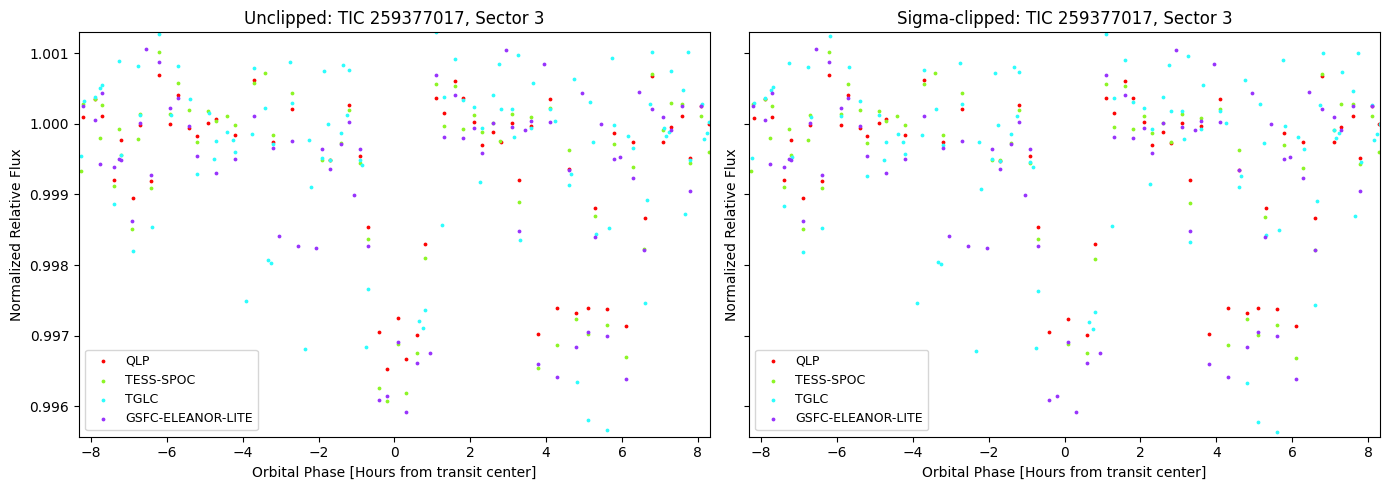

 
target_to_lightcurve_workflow function took: 48.779 seconds 

 


In [5]:
sector_results = target_to_lightcurve_workflow(target=target, pipelines=pipelines, target_Sector=None,
                             DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
                             DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH)

In [6]:
print(type(sector_results),'\n')
print(sector_results.keys(),'\n')
print(sector_results['TGLC'].keys())

dict

# Dax's suggestions for patching helper functions in "standardizing_data.py"

# # Problem in get_tess_lc: 

The MAST search is always run (acceptable,  it's pretty fast), but product.download() re-fetches the FITS even if it already exists locally. The fix is a JSON cache index mapping a unique product key → local path, checked between search selection and download.

In [9]:
"""
Drop-in additions/replacements for standardizing_data.py.

Changes vs. original
--------------------
1. _load_fits_cache / _update_fits_cache  — JSON-backed FITS path index
2. get_tess_lc                            — full replacement; adds use_cache kwarg
3. save_pipeline_results                  — persist collect_lightcurves_for_target
                                            output as Parquet + JSON metadata
4. load_pipeline_results                  — reload a saved results dict from disk

Requires: json (stdlib), same imports as standardizing_data.py
"""
from __future__ import annotations

import json
import os
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
import lksearch as lk

# ---------------------------------------------------------------------------
# Module-level constant
# ---------------------------------------------------------------------------
_CACHE_INDEX_FILENAME = "hlsp_fits_cache.json"


# ---------------------------------------------------------------------------
# 1.  Cache helpers
# ---------------------------------------------------------------------------

def _load_fits_cache(downloadpath: str) -> Dict[str, str]:
    """
    Load the local FITS cache index from ``{downloadpath}/hlsp_fits_cache.json``.

    Returns an empty dict if the file does not yet exist.

    Parameters
    ----------
    downloadpath : str
        Directory where HLSP files are (or will be) stored.

    Returns
    -------
    index : dict
        Mapping of cache_key (str) -> absolute local file path (str).

    Examples
    --------
    >>> idx = _load_fits_cache("/data/HLSP")
    >>> idx.get("259377017__QLP__3__30_minute")
    '/data/HLSP/mastDownload/HLSP/.../file.fits'
    """
    index_path = os.path.join(downloadpath, _CACHE_INDEX_FILENAME)
    if os.path.exists(index_path):
        with open(index_path, "r") as fh:
            return json.load(fh)
    return {}


def _update_fits_cache(downloadpath: str, key: str, local_path: str) -> None:
    """
    Add or update one entry in the FITS cache index and write it to disk.

    Parameters
    ----------
    downloadpath : str
        Directory where the cache index lives.
    key : str
        Cache key for this product (see ``_build_fits_cache_key``).
    local_path : str
        Absolute path to the downloaded FITS file.

    Examples
    --------
    >>> _update_fits_cache("/data/HLSP", "259377017__QLP__3__30_minute",
    ...                    "/data/HLSP/mastDownload/HLSP/qlp.fits")
    """
    os.makedirs(downloadpath, exist_ok=True)
    index = _load_fits_cache(downloadpath)
    index[key] = local_path
    index_path = os.path.join(downloadpath, _CACHE_INDEX_FILENAME)
    with open(index_path, "w") as fh:
        json.dump(index, fh, indent=2)


def _build_fits_cache_key(
    best_tbl: pd.DataFrame,
    tic_str: str,
    pipeline: str,
    exptime: str,
) -> str:
    """
    Build a deterministic cache key for a single HLSP product.

    Strategy (priority order):
    1. Use ``dataURI`` / ``obs_id`` / ``productFilename`` from the product table
       — these are MAST-assigned unique identifiers.
    2. Fall back to ``(tic_str, pipeline, sector, exptime)`` constructed from
       the selected product row.

    Parameters
    ----------
    best_tbl : pd.DataFrame
        Single-row product table as selected inside ``get_tess_lc``.
    tic_str : str
        Normalised TIC identifier string (no leading zeros or ".0").
    pipeline : str
        HLSP pipeline name.
    exptime : str
        Cadence/exposure-time string (e.g. ``"30 minute"``).

    Returns
    -------
    key : str
        Cache key string safe for use as a JSON dict key.

    Examples
    --------
    >>> key = _build_fits_cache_key(best_tbl, "259377017", "QLP", "30 minute")
    >>> key
    '259377017__QLP__3__30_minute'
    """
    # Attempt to derive key from MAST product-level identifiers first
    for uri_col in ("dataURI", "dataurl", "obs_id", "obsid", "productFilename"):
        for col in best_tbl.columns:
            if col.lower().replace("_", "") == uri_col.lower().replace("_", ""):
                val = str(best_tbl[col].iloc[0]).strip()
                if val and val.lower() not in {"nan", "none", ""}:
                    # Sanitise for use as a JSON key (no path separators)
                    safe = val.replace("/", "__").replace("\\", "__")
                    return safe

    # Fallback: construct from (tic, pipeline, sector, exptime)
    sector_val = "None"
    for s_col in ("sector", "sequence_number", "year"):
        if s_col in best_tbl.columns:
            raw = str(best_tbl[s_col].iloc[0]).strip()
            if raw.lower() not in {"nan", "none", ""}:
                sector_val = raw
                break

    safe_exptime = exptime.replace(" ", "_")
    return f"{tic_str}__{pipeline}__{sector_val}__{safe_exptime}"


# ---------------------------------------------------------------------------
# 2.  get_tess_lc — full replacement with caching
# ---------------------------------------------------------------------------

def get_tess_lc(
    TIC_ID: Union[int, str],
    pipeline: str,
    radius: u.Quantity = DEFAULT_RADIUS,
    exptime: str = DEFAULT_CADENCE,
    Sector: Optional[Union[int, List[int]]] = None,
    downloadpath: str = DEFAULT_DOWNLOADPATH,
    *,
    verbose: bool = True,
    choose_first_timeseries: bool = True,
    use_cache: bool = True,
) -> Tuple[Any, pd.DataFrame, pd.DataFrame]:
    """
    Download one TESS HLSP light curve (FITS) via lksearch and return it
    as a pair of DataFrames (raw, standardized).  Previously downloaded
    products are served from a local JSON-backed cache — the FITS file is
    not re-fetched as long as it still exists on disk.

    Parameters
    ----------
    TIC_ID : int | str
        TIC identifier.
    pipeline : str
        HLSP pipeline name (e.g. ``"QLP"``, ``"TESS-SPOC"``).
    radius : astropy.units.Quantity
        Cone-search radius.
    exptime : str
        Exposure-time / cadence key (e.g. ``"30 minute"``).
    Sector : int | list[int] | None
        TESS sector(s) to filter on.
    downloadpath : str
        Directory where products are (or will be) stored.
    verbose : bool
        Print progress / selected-product summary.
    choose_first_timeseries : bool
        If True, prefer the earliest time-series product when multiple rows
        match.
    use_cache : bool
        If True (default), consult the local JSON cache before calling
        ``product.download()``.  Set to False to force a fresh download.

    Returns
    -------
    product : lksearch.TESSSearch
        Single-row TESSSearch object for the selected product.
    raw_df : pd.DataFrame
        Light-curve table read directly from the FITS BinTable extension.
    std_df : pd.DataFrame
        Standardized DataFrame via ``standardize_lc``.

    Raises
    ------
    ValueError
        If no matching HLSP timeseries product is found, or if the
        download manifest is empty.

    Notes
    -----
    Cache index is written to ``{downloadpath}/hlsp_fits_cache.json``.
    A cache entry is invalidated automatically if the recorded file path
    no longer exists on disk (stale entry).

    Examples
    --------
    >>> product, raw_df, std_df = get_tess_lc(259377017, "QLP", Sector=3)
    >>> product, raw_df, std_df = get_tess_lc(259377017, "QLP", Sector=3)
    # Second call reads from cache — no download.
    """
    import re  # local re import (already in stdlib)

    os.makedirs(downloadpath, exist_ok=True)

    # --- Normalise TIC string ---
    tic_str = str(TIC_ID).strip()
    try:
        tic_str = str(int(float(tic_str)))
    except Exception:
        pass

    search_radius = (
        float(radius) if isinstance(radius, (int, float, np.floating)) else radius
    )

    # ------------------------------------------------------------------ #
    #  MAST search (always run — it is fast and determines which file     #
    #  to serve from cache).                                              #
    # ------------------------------------------------------------------ #
    search = lk.TESSSearch(
        target=f"TIC {tic_str}",
        search_radius=search_radius,
        exptime=exptime,
        sector=Sector,
        hlsp=True,
    )
    try:
        ts = search.timeseries
    except Exception:
        ts = search

    filtered = ts.filter_table(mission="HLSP", pipeline=pipeline)

    if filtered.table is None or len(filtered.table) == 0:
        table = getattr(ts, "table", None)
        if isinstance(table, pd.DataFrame) and len(table) > 0:
            hlsp_tbl = (
                table[table["mission"].astype(str).eq("HLSP")]
                if "mission" in table.columns
                else table
            )
            avail = (
                np.unique(hlsp_tbl["pipeline"].astype(str))
                if "pipeline" in hlsp_tbl.columns and len(hlsp_tbl) > 0
                else np.array([])
            )
            raise ValueError(
                f"No HLSP timeseries product found for pipeline='{pipeline}' "
                f"(TIC={tic_str}, sector={Sector}, exptime={exptime}, "
                f"radius={radius}). Available HLSP pipelines: {avail.tolist()}"
            )
        raise ValueError(
            f"No products returned at all for TIC={tic_str}, sector={Sector}, "
            f"exptime={exptime}, radius={radius}."
        )

    tbl = filtered.table.copy()

    # ------------------------------------------------------------------ #
    #  Row selection (identical logic to original)                        #
    # ------------------------------------------------------------------ #
    sort_cols: List[str] = []
    time_col_used = None

    if choose_first_timeseries:
        for candidate in ["t_min", "tstart", "t_min_btjd", "start_time", "year"]:
            if candidate in tbl.columns:
                sort_cols.append(candidate)
                time_col_used = candidate
                break
        if "distance" in tbl.columns:
            sort_cols.append("distance")
        if not sort_cols and "description" in tbl.columns:
            sort_cols = ["description"]
        elif not sort_cols and "distance" in tbl.columns:
            sort_cols = ["distance"]
    else:
        if "distance" in tbl.columns:
            sort_cols = ["distance"]
        elif "t_min" in tbl.columns:
            sort_cols = ["t_min"]

    if sort_cols:
        tbl = tbl.sort_values(sort_cols, ascending=True).reset_index(drop=True)

    best_tbl = tbl.iloc[[0]].copy()
    product = lk.TESSSearch(table=best_tbl)

    if verbose:
        cols = [
            c for c in
            ["target_name", "pipeline", "mission", "sector", "exptime",
             "distance", "year", "description"]
            if c in best_tbl.columns
        ]
        print("Selected product row:")
        print(best_tbl[cols] if cols else best_tbl.head(1))
        if choose_first_timeseries:
            print(f"choose_first_timeseries=True; sorted using: {time_col_used}")

    # ------------------------------------------------------------------ #
    #  Cache lookup — skip download if FITS already on disk              #
    # ------------------------------------------------------------------ #
    cache_key = _build_fits_cache_key(best_tbl, tic_str, pipeline, exptime)
    local_path: Optional[str] = None

    if use_cache:
        cache_index = _load_fits_cache(downloadpath)
        cached_path = cache_index.get(cache_key)
        if cached_path and os.path.isfile(cached_path):
            if verbose:
                print(f"[cache hit]  {pipeline} TIC={tic_str} → {cached_path}")
            local_path = cached_path
        elif cached_path:
            if verbose:
                print(
                    f"[cache stale] recorded path no longer exists: {cached_path}\n"
                    f"              Re-downloading..."
                )

    # ------------------------------------------------------------------ #
    #  Download (only if no valid cached path found)                      #
    # ------------------------------------------------------------------ #
    if local_path is None:
        manifest = product.download(download_dir=downloadpath)

        if not isinstance(manifest, pd.DataFrame) or len(manifest) == 0:
            raise ValueError(
                "Download returned an empty manifest; nothing was downloaded."
            )

        path_col = None
        for c in manifest.columns:
            canon = c.lower().replace(" ", "").replace("_", "")
            if canon == "localpath":
                path_col = c
                break

        if path_col is None:
            raise ValueError(
                f"Could not find Local Path column in manifest. "
                f"Columns: {list(manifest.columns)}"
            )

        local_path = str(manifest[path_col].iloc[0])

        if use_cache:
            _update_fits_cache(downloadpath, cache_key, local_path)
            if verbose:
                print(f"[cache write] {cache_key} → {local_path}")

    # ------------------------------------------------------------------ #
    #  Read FITS → DataFrame → standardize                               #
    # ------------------------------------------------------------------ #
    with fits.open(local_path, memmap=False) as hdul:
        table_hdu = None
        for hdu in hdul[1:]:
            data = getattr(hdu, "data", None)
            if data is None:
                continue
            extname = str(getattr(hdu, "name", "")).upper()
            if hasattr(data, "names") and extname in {
                "LIGHTCURVE", "LIGHTCURVES", "LC", "TIME_SERIES", "TIMESERIES"
            }:
                table_hdu = hdu
                break
            if table_hdu is None and hasattr(data, "names"):
                table_hdu = hdu

        if table_hdu is None:
            raise ValueError(
                f"No table-like FITS extension found in file: {local_path}"
            )

        rec = np.array(table_hdu.data)
        if hasattr(rec.dtype, "isnative") and not rec.dtype.isnative:
            try:
                rec = rec.byteswap().newbyteorder()
            except AttributeError:
                rec = rec.byteswap().view(rec.dtype.newbyteorder("="))

        raw_df = pd.DataFrame.from_records(rec)
        std_df = standardize_lc(raw_df, pipeline)

    return product, raw_df, std_df


# ---------------------------------------------------------------------------
# 3.  Persist / reload results from collect_lightcurves_for_target
# ---------------------------------------------------------------------------

class _NumpyEncoder(json.JSONEncoder):
    """JSON encoder that handles numpy scalar types from pandas/.item() calls."""
    def default(self, o: Any) -> Any:
        if isinstance(o, np.integer):
            return int(o)
        if isinstance(o, np.floating):
            return float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        return super().default(o)


def save_pipeline_results(
    results: Dict[str, Dict[str, Any]],
    savepath: str,
    tic_id: Union[int, str],
    sector: int,
    *,
    overwrite: bool = False,
) -> str:
    """
    Persist the output of ``collect_lightcurves_for_target`` to disk.

    Layout on disk::

        {savepath}/
          TIC{tic_id}_S{sector}/
            metadata.json                    ← status, errors, row counts
            {PIPELINE}_raw.parquet
            {PIPELINE}_standardized.parquet
            {PIPELINE}_standardized_masked.parquet

    Parquet is used for DataFrames (fast I/O, exact dtype preservation).
    ``None`` DataFrames (failed pipelines or disabled masking) are skipped
    silently — their absence is recorded in ``metadata.json``.

    Parameters
    ----------
    results : dict
        As returned by ``collect_lightcurves_for_target``.
    savepath : str
        Root directory under which the ``TIC{id}_S{sector}/`` folder is
        created.
    tic_id : int | str
        TIC identifier (used only for the folder name).
    sector : int
        Sector number (used only for the folder name).
    overwrite : bool
        If False (default) and the target directory already exists, raise
        FileExistsError.  If True, existing files are overwritten silently.

    Returns
    -------
    outdir : str
        Absolute path to the ``TIC{tic_id}_S{sector}/`` directory.

    Raises
    ------
    FileExistsError
        If the output directory already exists and ``overwrite=False``.

    Examples
    --------
    >>> outdir = save_pipeline_results(results, "/data/comparisons",
    ...                                tic_id=259377017, sector=3)
    >>> print(outdir)
    /data/comparisons/TIC259377017_S3
    """
    outdir = os.path.join(savepath, f"TIC{tic_id}_S{sector}")
    if os.path.exists(outdir) and not overwrite:
        raise FileExistsError(
            f"Output directory already exists: {outdir}\n"
            "Pass overwrite=True to replace existing files."
        )
    os.makedirs(outdir, exist_ok=True)

    metadata: Dict[str, Any] = {}

    for pipeline, info in results.items():
        meta_entry: Dict[str, Any] = {
            "tic_id": str(info.get("tic_id", tic_id)),
            "sector": info.get("sector", sector),
            "pipeline": pipeline,
            "status": info.get("status", "unknown"),
            "error": info.get("error"),
            "n_raw": info.get("n_raw"),
            "n_standardized": info.get("n_standardized"),
            "n_masked": info.get("n_masked"),
            "files": {},
        }

        for key in ("raw", "standardized", "standardized_masked"):
            df = info.get(key)
            if df is not None and not df.empty:
                fname = f"{pipeline}_{key}.parquet"
                fpath = os.path.join(outdir, fname)
                df.to_parquet(fpath, index=False)
                meta_entry["files"][key] = fname

        metadata[pipeline] = meta_entry

    meta_path = os.path.join(outdir, "metadata.json")
    with open(meta_path, "w") as fh:
        json.dump(metadata, fh, indent=2, cls=_NumpyEncoder)

    return outdir


def load_pipeline_results(
    savepath: str,
    tic_id: Union[int, str],
    sector: int,
) -> Dict[str, Dict[str, Any]]:
    """
    Reload a results dict previously saved by ``save_pipeline_results``.

    Reconstructs the same structure as ``collect_lightcurves_for_target``
    (minus the ``product`` field, which is not serialised).

    Parameters
    ----------
    savepath : str
        Root directory passed to ``save_pipeline_results``.
    tic_id : int | str
        TIC identifier.
    sector : int
        Sector number.

    Returns
    -------
    results : dict
        Keyed by pipeline name.  Each value has:
        ``raw``, ``standardized``, ``standardized_masked`` (DataFrames or
        None), plus all scalar metadata fields.  ``product`` is always None.

    Raises
    ------
    FileNotFoundError
        If the expected directory or ``metadata.json`` is missing.

    Examples
    --------
    >>> results = load_pipeline_results("/data/comparisons", 259377017, 3)
    >>> results["QLP"]["standardized"].head()
    """
    outdir = os.path.join(savepath, f"TIC{tic_id}_S{sector}")
    meta_path = os.path.join(outdir, "metadata.json")

    if not os.path.isdir(outdir):
        raise FileNotFoundError(f"Results directory not found: {outdir}")
    if not os.path.isfile(meta_path):
        raise FileNotFoundError(f"metadata.json not found in: {outdir}")

    try:
        with open(meta_path, "r") as fh:
            metadata = json.load(fh)
    except json.JSONDecodeError as exc:
        raise FileNotFoundError(
            f"metadata.json at {meta_path} is corrupt (truncated by a prior "
            f"failed write). Treating as cache miss. Original error: {exc}\n"
            f"The directory will be overwritten on next save."
        ) from exc

    results: Dict[str, Dict[str, Any]] = {}

    for pipeline, meta in metadata.items():
        entry: Dict[str, Any] = {
            "product": None,  # not serialised
            "raw": None,
            "standardized": None,
            "standardized_masked": None,
            "tic_id": meta.get("tic_id"),
            "sector": meta.get("sector"),
            "pipeline": pipeline,
            "n_raw": meta.get("n_raw"),
            "n_standardized": meta.get("n_standardized"),
            "n_masked": meta.get("n_masked"),
            "status": meta.get("status"),
            "error": meta.get("error"),
        }

        for key in ("raw", "standardized", "standardized_masked"):
            fname = meta.get("files", {}).get(key)
            if fname:
                fpath = os.path.join(outdir, fname)
                if os.path.isfile(fpath):
                    entry[key] = pd.read_parquet(fpath)

        results[pipeline] = entry

    return results

# New workflow with patched solutions above

In [10]:
def target_to_lightcurve_workflow(
    target,
    pipelines,
    target_Sector,
    DEFAULT_RADIUS,
    DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH,
    *,
    save_results: bool = True,
    results_savepath: str = None,
    force_redownload: bool = False,
):
    """
    Phase-fold and compare TESS HLSP light curves across multiple pipelines
    for a single target, with disk-backed caching of both FITS files and
    standardized DataFrames.

    On first call for a given (TIC, sector) pair, the function downloads all
    requested pipelines via ``collect_lightcurves_for_target`` and optionally
    persists the standardized results to Parquet on disk.  On subsequent
    calls, it attempts to load results from disk — skipping all network I/O —
    and only falls back to a live download if the saved data are not found.

    Parameters
    ----------
    target : pd.Series or single-row pd.DataFrame
        Row from the nearby TOI / M-dwarf catalog.  Must contain:
        ``'TIC ID'``, ``'Orbital Period (days) Value'``,
        ``'Orbital Epoch Value'``, ``'Transit Depth Value'``,
        ``'Transit Duration (hours) Value'``, and ``'Sectors'``.
    pipelines : list of str
        Pipeline names to compare (e.g. ``["QLP", "TESS-SPOC", "TGLC",
        "GSFC-ELEANOR-LITE"]``).
    target_Sector : int or None
        TESS sector to use.  If None, the first (earliest) sector listed in
        ``target['Sectors']`` is selected automatically.
    DEFAULT_RADIUS : astropy.units.Quantity
        Cone-search radius passed to ``collect_lightcurves_for_target``.
    DEFAULT_CADENCE : str
        Cadence/exptime string passed to ``collect_lightcurves_for_target``.
    DEFAULT_DOWNLOADPATH : str
        Root directory for FITS downloads and the FITS cache index.
    save_results : bool, optional
        If True (default), persist standardized DataFrames to Parquet after a
        live download run.  Has no effect when results are loaded from disk.
    results_savepath : str or None, optional
        Root directory for saved Parquet results.  Defaults to
        ``DEFAULT_DOWNLOADPATH + "/saved_results"`` if not provided.
    force_redownload : bool, optional
        If True, skip the disk cache entirely and re-run
        ``collect_lightcurves_for_target`` from scratch.  Useful when the
        on-disk data are stale or a pipeline has been updated.

    Returns
    -------
    sector_results : dict
        The results dict as returned by ``collect_lightcurves_for_target``
        (or reconstructed from disk by ``load_pipeline_results``).

    Examples
    --------
    >>> target = nearby_TOI_MD_df.loc[
    ...     nearby_TOI_MD_df['TIC ID'].astype(int) == 259377017
    ... ].reset_index(drop=True).iloc[0]
    >>> pipelines = ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
    >>> pipeline_colors = _get_colors(len(pipelines))
    >>> results = target_to_lightcurve_workflow(
    ...     target=target,
    ...     pipelines=pipelines,
    ...     target_Sector=None,
    ...     DEFAULT_RADIUS=DEFAULT_RADIUS,
    ...     DEFAULT_CADENCE=DEFAULT_CADENCE,
    ...     DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    ... )
    """
    import time as clock
    t_start = clock.time()
    # ------------------------------------------------------------------ #
    #  Unpack target metadata                                             #
    # ------------------------------------------------------------------ #
    ID          = target['TIC ID'].item()
    target_P    = target['Orbital Period (days) Value'].item()
    target_T0   = target['Orbital Epoch Value'].item()
    target_Dep  = target['Transit Depth Value'].item() / 1e6
    target_Dur  = target['Transit Duration (hours) Value'].item()

    if target_Sector is None:
        try:
            target_Sector = np.min(
                list(map(int, target['Sectors'].to_list()[0].split(',')))
            )
        except AttributeError:
            target_Sector = np.min(
                list(map(int, target['Sectors'].split(',')))
            )

    if results_savepath is None:
        results_savepath = os.path.join(DEFAULT_DOWNLOADPATH, "saved_results")

    # ------------------------------------------------------------------ #
    #  Cache layer: try loading from disk first                           #
    # ------------------------------------------------------------------ #
    sector_results = None

    if not force_redownload:
        try:
            sector_results = load_pipeline_results(
                savepath=results_savepath,
                tic_id=ID,
                sector=target_Sector,
            )
            print(
                f"[cache hit] Loaded saved results for TIC {ID}, "
                f"sector {target_Sector} from {results_savepath}"
            )
        except FileNotFoundError:
            print(
                f"[cache miss] No saved results found for TIC {ID}, "
                f"sector {target_Sector} — running live download."
            )

    # ------------------------------------------------------------------ #
    #  Live download (first run, or force_redownload=True)               #
    # ------------------------------------------------------------------ #
    if sector_results is None:
        sector_results = collect_lightcurves_for_target(
            tic_id=ID,
            sector=target_Sector,
            pipelines=pipelines,
            downloadpath=DEFAULT_DOWNLOADPATH,
            radius=DEFAULT_RADIUS,
            exptime=DEFAULT_CADENCE,
            apply_quality_mask=True,
            verbose=True,
        )

        if save_results:
            try:
                outdir = save_pipeline_results(
                    results=sector_results,
                    savepath=results_savepath,
                    tic_id=ID,
                    sector=target_Sector,
                    overwrite=force_redownload,
                )
                print(f"[saved] Results written to {outdir}")
            except FileExistsError:
                # Results directory already exists and overwrite=False.
                # This branch is only reachable if save_results=True but
                # force_redownload=False and the saved dir exists without a
                # readable metadata.json (edge case: partial prior write).
                print(
                    "[warning] Could not save results — directory exists. "
                    "Pass force_redownload=True to overwrite."
                )

    # ------------------------------------------------------------------ #
    #  Phase-folded comparison plot                                       #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    corrected_epochs    = {}
    epoch_btjd          = target_T0
    period              = target_P
    sector_all_flux_unclipped = []
    sector_all_flux_clipped   = []

    for i, p in enumerate(pipelines):
        info = sector_results[p]
        C    = pipeline_colors[i]

        if info["status"] != "ok":
            corrected_epochs[p] = None
            continue

        lc_to_plot = info["standardized_masked"]
        if lc_to_plot is None or lc_to_plot.empty:
            lc_to_plot = info["standardized"]
        if lc_to_plot is None or lc_to_plot.empty:
            corrected_epochs[p] = None
            continue

        t_first  = lc_to_plot["time"].min()
        flux     = lc_to_plot["flux_corr"].to_numpy()
        n_first  = int(np.ceil((t_first - epoch_btjd) / period))
        corrected_epochs[p] = epoch_btjd + n_first * period

        flux_norm = flux / np.nanmedian(flux)
        clipped   = sigma_clip(
            flux_norm, sigma=3, sigma_lower=7, sigma_upper=3, maxiters=5
        )
        good      = ~clipped.mask
        lc_clean  = lc_to_plot.iloc[good]

        n_total   = len(flux_norm)
        n_removed = np.sum(clipped.mask)
        print(f"{p}: total {n_total} points, removed {n_removed} via sigma-clip")

        plot_phasefolded(
            ax=axes[0], target=target, lc=lc_to_plot,
            color=C, label=p, T0=corrected_epochs[p],
        )
        plot_phasefolded(
            ax=axes[1], target=target, lc=lc_clean,
            color=C, label=p, T0=corrected_epochs[p],
        )

        sector_all_flux_unclipped.append(flux_norm)
        sector_all_flux_clipped.append(flux_norm[good])

    if sector_all_flux_unclipped:
        all_flux_unclipped = np.concatenate(sector_all_flux_unclipped)
        axes[0].set_ylim(
            np.nanpercentile(all_flux_unclipped, 1),
            np.nanpercentile(all_flux_unclipped, 99),
        )
    if sector_all_flux_clipped:
        all_flux_clipped = np.concatenate(sector_all_flux_clipped)
        axes[1].set_ylim(
            np.nanpercentile(all_flux_clipped, 1),
            np.nanpercentile(all_flux_clipped, 99),
        )

    for ax in axes:
        ax.set_xlabel("Orbital Phase [Hours from transit center]")
        ax.set_ylabel("Normalized Relative Flux")
        ax.legend(loc="best", fontsize=9)

    axes[0].set_title(f"Unclipped: TIC {ID}, Sector {target_Sector}")
    axes[1].set_title(f"Sigma-clipped: TIC {ID}, Sector {target_Sector}")
    plt.tight_layout()
    plt.show()
    
    print(' ')
    print('================================')
    timer(t_start, clock.time(), "target_to_lightcurve_workflow function took:")
    print(' ')
    print('================================')
    
    return sector_results

In [11]:
DEFAULT_DOWNLOADPATH

'/Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/'

[cache hit] Loaded saved results for TIC 259377017, sector 3 from /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/saved_results
QLP: total 857 points, removed 2 via sigma-clip
TESS-SPOC: total 857 points, removed 24 via sigma-clip
TGLC: total 1077 points, removed 50 via sigma-clip
GSFC-ELEANOR-LITE: total 789 points, removed 2 via sigma-clip


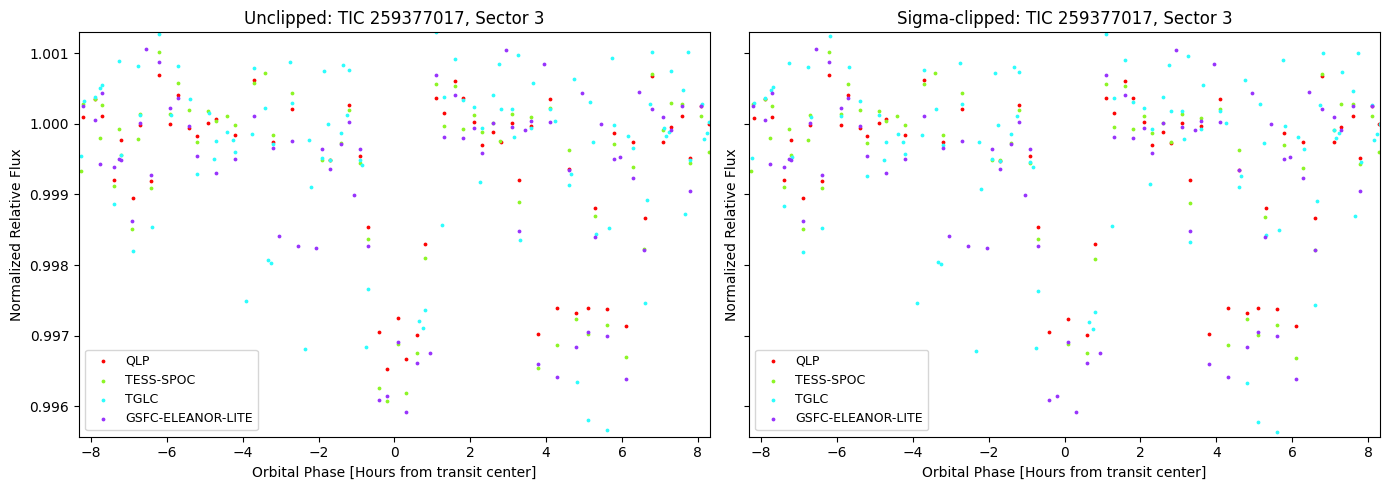

 
target_to_lightcurve_workflow function took: 0.294 seconds 

 


In [12]:
sector_results = target_to_lightcurve_workflow(
    target=target, pipelines=pipelines, target_Sector=None,
    DEFAULT_RADIUS=DEFAULT_RADIUS, DEFAULT_CADENCE=DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH=DEFAULT_DOWNLOADPATH,
    save_results=True
)



In [13]:
print(sector_results.keys(),'\n')

print(sector_results['TGLC'].keys())

dict_keys(['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE']) 

dict_keys(['product', 'raw', 'standardized', 'standardized_masked', 'tic_id', 'sector', 'pipeline', 'n_raw', 'n_standardized', 'n_masked', 'status', 'error'])


# example of reading in .parquet file.


# Why .parquet? Parquet is a binary columnar file format,  think of it as a more efficient CSV that preserves column dtypes exactly (no float precision loss, no re-parsing strings as dates, etc.). It's from the data engineering world so it's less common in astronomy pipelines. Useful to know!

# JSON (JavaScript Object Notation) is just a structured text file,  you can open it in any text editor. In this context metadata.json only stores the scalar bookkeeping fields (status, n_raw, n_masked, error, etc.), not any flux data.

In [15]:
import pandas as pd

# Read any of the saved parquet files directly
df = pd.read_parquet("HLSP/saved_results/TIC259377017_S3/QLP_standardized.parquet")
print(df.head())
print(df.dtypes)
print(df.shape)
print('\n========================================\n')
print('\n========================================\n')
print('\n========================================\n')

# metadata.json is plain text — just read it
import json
with open("HLSP/saved_results/TIC259377017_S3/metadata.json") as f:
    print(json.dumps(json.load(f), indent=2))

          time  flux_raw  flux_raw_err  flux_corr  flux_corr_err     flux_bkg  \
0  1381.720593  1.000283           NaN   1.000523       0.000347 -3288.439941   
1  1381.741427  0.999296           NaN   0.999452       0.000347 -3356.010010   
2  1381.762261  1.001356           NaN   1.001439       0.000347 -3983.729980   
3  1381.783095  1.000606           NaN   1.000622       0.000347 -4010.860107   
4  1381.803928  0.999527           NaN   0.999484       0.000347 -3905.050049   

   flux_bkg_err  quality  
0    866.369995     4096  
1    599.760010     4096  
2    905.359985     4096  
3    935.330017     4096  
4    832.419983     4096  
time             float64
flux_raw         float32
flux_raw_err     float64
flux_corr        float32
flux_corr_err    float32
flux_bkg         float32
flux_bkg_err     float32
quality            int32
dtype: object
(1304, 8)






{
  "QLP": {
    "tic_id": "259377017",
    "sector": 3,
    "pipeline": "QLP",
    "status": "ok",
    "error": null,
  